In [1]:
# ── CELL 1: Imports ──────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_DIR  = os.path.expanduser("~/GeoAID_Project")
DATA_DIR     = os.path.join(PROJECT_DIR, "data")
OUTPUTS_DIR  = os.path.join(PROJECT_DIR, "outputs")
FIGURES_DIR  = os.path.join(OUTPUTS_DIR, "figures")
RESAMPLED_DIR= os.path.join(DATA_DIR, "resampled")

for d in [FIGURES_DIR, RESAMPLED_DIR]:
    os.makedirs(d, exist_ok=True)

print("✓ Libraries imported")
print(f"  Data directory     : {DATA_DIR}")
print(f"  Resampled directory: {RESAMPLED_DIR}")
print(f"  Figures directory  : {FIGURES_DIR}")

✓ Libraries imported
  Data directory     : /home/deysholey/GeoAID_Project/data
  Resampled directory: /home/deysholey/GeoAID_Project/data/resampled
  Figures directory  : /home/deysholey/GeoAID_Project/outputs/figures


In [2]:
# ── CELL 2: Verify Required Files ────────────────────────────────────────────
# Confirm all five GeoTIFFs and the training CSV are present
# before running any processing. Fail early rather than discovering
# a missing file midway through the resampling pipeline.

required_files = {
    'topo_features_amuwo_odofin.tif'          : 'Features 1-6  (topographic)',
    'rainfall_lulc_ndvi_amuwo_odofin.tif'     : 'Features 7-11 (climate + land cover)',
    'soil_distance_amuwo_odofin.tif'           : 'Features 12-14 (soil + distance)',
    'gpm_antecedent_rainfall_amuwo_odofin.tif' : 'Feature 15   (GPM IMERG rainfall)',
    'training_points_amuwo_odofin.csv': 'Training labels (10,000 points)'
}

print("File verification:")
print()

all_present = True
for filename, description in required_files.items():
    filepath = os.path.join(DATA_DIR, filename)
    if os.path.exists(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  ✓ {filename}")
        print(f"    {description} | {size_mb:.2f} MB")
    else:
        print(f"  ✗ MISSING: {filename}")
        print(f"    {description}")
        all_present = False
    print()

if all_present:
    print("✓ All required files present — ready to proceed")
else:
    raise FileNotFoundError("Download missing files from Google Drive before proceeding")

File verification:

  ✓ topo_features_amuwo_odofin.tif
    Features 1-6  (topographic) | 2.11 MB

  ✓ rainfall_lulc_ndvi_amuwo_odofin.tif
    Features 7-11 (climate + land cover) | 0.13 MB

  ✓ soil_distance_amuwo_odofin.tif
    Features 12-14 (soil + distance) | 0.12 MB

  ✓ gpm_antecedent_rainfall_amuwo_odofin.tif
    Feature 15   (GPM IMERG rainfall) | 0.00 MB

  ✓ training_points_amuwo_odofin.csv
    Training labels (10,000 points) | 1.00 MB

✓ All required files present — ready to proceed


In [3]:
# ── CELL 3: Inspect Raster Metadata ──────────────────────────────────────────
# Before resampling, confirm each raster's resolution, CRS, band count,
# and spatial extent. All should share EPSG:4326 CRS and approximately
# the same bounding box (Amuwo Odofin LGA extent).
# Resolutions will differ — harmonised to 100m in Cell 4.

raster_files = {
    'topographic'         : 'topo_features_amuwo_odofin.tif',
    'rainfall_lulc_ndvi'  : 'rainfall_lulc_ndvi_amuwo_odofin.tif',
    'soil_distance'       : 'soil_distance_amuwo_odofin.tif',
    'gpm_rainfall'        : 'gpm_antecedent_rainfall_amuwo_odofin.tif'
}

# Expected band names for each file — used in spatial join (Cell 6)
BAND_NAMES = {
    'topographic'        : ['elevation', 'slope', 'aspect',
                            'flow_accumulation', 'twi', 'curvature'],
    'rainfall_lulc_ndvi' : ['mean_annual_rainfall', 'mean_rainy_days',
                            'extreme_rain_freq', 'lulc', 'ndvi'],
    'soil_distance'      : ['soil_permeability', 'distance_to_river',
                            'distance_to_drainage'],
    'gpm_rainfall'       : ['gpm_antecedent_rainfall']
}

print("=" * 60)
print("  RASTER METADATA INSPECTION")
print("=" * 60)

for name, filename in raster_files.items():
    filepath = os.path.join(DATA_DIR, filename)
    with rasterio.open(filepath) as src:
        pixel_w_m = abs(src.transform.a) * 111000
        pixel_h_m = abs(src.transform.e) * 111000
        print(f"\n  {name.upper()}")
        print(f"  File       : {filename}")
        print(f"  Bands      : {src.count}")
        print(f"  CRS        : {src.crs}")
        print(f"  Resolution : ~{pixel_w_m:.0f}m x {pixel_h_m:.0f}m")
        print(f"  Dimensions : {src.width} x {src.height} pixels")
        print(f"  Bounds     : {src.bounds}")
        print(f"  NoData     : {src.nodata}")

print("\n✓ Metadata inspection complete")
print("  All rasters will be resampled to 100m in Cell 4")

  RASTER METADATA INSPECTION

  TOPOGRAPHIC
  File       : topo_features_amuwo_odofin.tif
  Bands      : 6
  CRS        : EPSG:4326
  Resolution : ~30m x 30m
  Dimensions : 687 x 489 pixels
  Bounds     : BoundingBox(left=3.18434801914688, bottom=6.3969929697435255, right=3.3694907992039136, top=6.528775821923859)
  NoData     : None

  RAINFALL_LULC_NDVI
  File       : rainfall_lulc_ndvi_amuwo_odofin.tif
  Bands      : 5
  CRS        : EPSG:4326
  Resolution : ~100m x 100m
  Dimensions : 206 x 147 pixels
  Bounds     : BoundingBox(left=3.184527682203704, bottom=6.396903138215112, right=3.3695806307323255, top=6.528955484980682)
  NoData     : None

  SOIL_DISTANCE
  File       : soil_distance_amuwo_odofin.tif
  Bands      : 3
  CRS        : EPSG:4326
  Resolution : ~100m x 100m
  Dimensions : 206 x 147 pixels
  Bounds     : BoundingBox(left=3.184527682203704, bottom=6.396903138215112, right=3.3695806307323255, top=6.528955484980682)
  NoData     : None

  GPM_RAINFALL
  File       : g

In [6]:
# ── CELL 4: Resample All Rasters to Common 100m Resolution ───────────────────
# All features must share identical resolution, extent, and CRS before
# the spatial join. Resampling to the coarsest resolution (100m) avoids
# information loss — no feature is downgraded below its native resolution
# more than necessary.
#
# Resampling methods:
# - Bilinear interpolation: continuous variables (elevation, rainfall,
#   NDVI, distance, soil, GPM). Weighted average of surrounding pixels
#   — preserves spatial gradients accurately.
# - Nearest neighbour: categorical variable (LULC class codes).
#   Bilinear on categorical data produces non-integer values that do
#   not correspond to valid land cover classes. Nearest neighbour
#   preserves the original class codes exactly.
#
# Target: EPSG:4326 at 0.0009° ≈ 100m at Lagos latitude (~6.5°N)

TARGET_RES = 0.0009   # degrees ≈ 100m at Lagos latitude
TARGET_CRS = 'EPSG:4326'

def resample_raster(input_path, output_path, target_res,
                    target_crs, resampling_method=Resampling.bilinear):
    """Reprojects and resamples raster to target resolution and CRS."""
    with rasterio.open(input_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, target_crs,
            src.width, src.height,
            *src.bounds,
            resolution=target_res
        )
        kwargs = src.meta.copy()
        kwargs.update({
            'crs'      : target_crs,
            'transform': transform,
            'width'    : width,
            'height'   : height,
            'dtype'    : 'float32',
            'nodata'   : -9999.0
        })
        with rasterio.open(output_path, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source       = rasterio.band(src, i),
                    destination  = rasterio.band(dst, i),
                    src_transform= src.transform,
                    src_crs      = src.crs,
                    dst_transform= transform,
                    dst_crs      = target_crs,
                    resampling   = resampling_method
                )
    return output_path

print("Resampling all rasters to 100m common grid...")
print()

resampled_paths = {}

for name, filename in raster_files.items():
    input_path  = os.path.join(DATA_DIR, filename)
    output_path = os.path.join(RESAMPLED_DIR, f"resampled_{filename}")

    # Use nearest neighbour for rainfall_lulc_ndvi because it contains
    # the LULC categorical band. All other rasters use bilinear.
    if name == 'rainfall_lulc_ndvi':
        method       = Resampling.nearest
        method_label = 'nearest-neighbour (contains LULC categorical band)'
    else:
        method       = Resampling.bilinear
        method_label = 'bilinear interpolation'

    resample_raster(input_path, output_path,
                    TARGET_RES, TARGET_CRS, method)

    resampled_paths[name] = output_path

    with rasterio.open(output_path) as src:
        pix_m = abs(src.transform.a) * 111000
        print(f"  ✓ {name}")
        print(f"    Method: {method_label}")
        print(f"    Output: {src.width}w x {src.height}h pixels @ {pix_m:.0f}m")

print()
print("✓ All rasters resampled to common 100m grid")
print(f"  Saved to: {RESAMPLED_DIR}")

Resampling all rasters to 100m common grid...

  ✓ topographic
    Method: bilinear interpolation
    Output: 206w x 147h pixels @ 100m
  ✓ rainfall_lulc_ndvi
    Method: nearest-neighbour (contains LULC categorical band)
    Output: 206w x 147h pixels @ 100m
  ✓ soil_distance
    Method: bilinear interpolation
    Output: 206w x 147h pixels @ 100m
  ✓ gpm_rainfall
    Method: bilinear interpolation
    Output: 210w x 150h pixels @ 100m

✓ All rasters resampled to common 100m grid
  Saved to: /home/deysholey/GeoAID_Project/data/resampled


In [9]:
# ── CELL 5: Load Training Points CSV ─────────────────────────────────────────
# GEE exports point coordinates embedded in a .geo column as GeoJSON.
# Parse to extract longitude and latitude, then convert to GeoDataFrame
# for spatial operations. Inspect raw columns first.

csv_path = os.path.join(DATA_DIR, 'training_points_amuwo_odofin.csv')
df_raw   = pd.read_csv(csv_path)

print(f"Raw CSV shape  : {df_raw.shape}")
print(f"Raw CSV columns: {df_raw.columns.tolist()}")
print()
print("First row preview:")
print(df_raw.head(1).to_string())
print()

# Parse coordinate columns — GEE exports vary in structure
# Common formats: .geo column (GeoJSON), or separate longitude/latitude columns
if '.geo' in df_raw.columns:
    import json
    print("Parsing coordinates from .geo column (GeoJSON format)...")

    def parse_geo(geo_str):
        try:
            geo = json.loads(geo_str)
            coords = geo['coordinates']
            return coords[0], coords[1]
        except Exception:
            return None, None

    df_raw[['longitude', 'latitude']] = df_raw['.geo'] \
        .apply(lambda x: pd.Series(parse_geo(x)))

elif 'longitude' in df_raw.columns and 'latitude' in df_raw.columns:
    print("Coordinates already in longitude/latitude columns")

elif 'lon' in df_raw.columns and 'lat' in df_raw.columns:
    df_raw = df_raw.rename(columns={'lon': 'longitude', 'lat': 'latitude'})
    print("Renamed lon/lat to longitude/latitude")

else:
    print("Available columns:", df_raw.columns.tolist())
    raise ValueError("Cannot identify coordinate columns — check CSV structure")

# Drop rows with missing coordinates
df_raw = df_raw.dropna(subset=['longitude', 'latitude'])

# Identify flood label column
if 'flood_label' in df_raw.columns:
    label_col = 'flood_label'
elif 'label' in df_raw.columns:
    label_col = 'label'
else:
    # Use first non-coordinate, non-geo column
    label_col = [c for c in df_raw.columns
                 if c not in ['.geo', 'longitude', 'latitude',
                              'system:index', 'lon', 'lat']][0]
    print(f"Using '{label_col}' as flood label column")

# Build GeoDataFrame
geometry = [Point(lon, lat) for lon, lat
            in zip(df_raw['longitude'], df_raw['latitude'])]

gdf = gpd.GeoDataFrame(
    df_raw[['longitude', 'latitude', label_col]].copy(),
    geometry = geometry,
    crs      = 'EPSG:4326'
)
gdf = gdf.rename(columns={label_col: 'flood_label'})

print(f"\n✓ Training points loaded: {len(gdf):,} points")
print(f"  Flood (1)     : {(gdf['flood_label']==1).sum():,}")
print(f"  Non-flood (0) : {(gdf['flood_label']==0).sum():,}")
print(f"  CRS           : {gdf.crs}")

Raw CSV shape  : (10000, 3)
Raw CSV columns: ['system:index', 'flood_label', '.geo']

First row preview:
  system:index  flood_label                                                                                    .geo
0          1_0            1  {"geodesic":false,"type":"Point","coordinates":[3.319769048227898,6.4019786195703885]}

Parsing coordinates from .geo column (GeoJSON format)...

✓ Training points loaded: 10,000 points
  Flood (1)     : 5,000
  Non-flood (0) : 5,000
  CRS           : EPSG:4326


In [10]:
# ── CELL 6: Spatial Join — Extract Feature Values at Sample Points ────────────
# For each of the 10,000 labelled sample points, extract the raster
# value at that point's location from every resampled feature layer.
#
# Method: rasterio.sample() — identifies which pixel each point falls
# in and returns that pixel's value across all bands. Equivalent to
# a spatial join or point sampling operation in GIS.
#
# This transforms:
#   INPUT : 10,000 points with (lon, lat, flood_label)
#   OUTPUT: 10,000 rows with (lon, lat, flood_label, F1, F2...F15)

def extract_raster_values(gdf, raster_path, band_names):
    """
    Extracts raster values at GeoDataFrame point locations.
    Returns DataFrame with one column per band.
    """
    coords  = [(geom.x, geom.y) for geom in gdf.geometry]
    with rasterio.open(raster_path) as src:
        sampled = np.array(list(src.sample(coords,
                                            masked=True)))
    # sampled shape: (n_points, n_bands)
    actual_bands = sampled.shape[1]
    if actual_bands != len(band_names):
        band_names = [f'band_{i+1}' for i in range(actual_bands)]
        print(f"    ⚠ Band count mismatch — using generic names")
    return pd.DataFrame(sampled, columns=band_names,
                        index=gdf.index)

print("Extracting feature values at 10,000 sample points...")
print()

feature_dfs = []
for name, raster_path in resampled_paths.items():
    band_cols = BAND_NAMES[name]
    feat_df   = extract_raster_values(gdf, raster_path, band_cols)
    feature_dfs.append(feat_df)
    print(f"  ✓ {name}: {len(band_cols)} features extracted")
    for col in band_cols:
        vals = feat_df[col]
        print(f"    {col}: min={vals.min():.2f}, "
              f"max={vals.max():.2f}, mean={vals.mean():.2f}")
    print()

# Assemble complete feature matrix
feature_matrix = pd.concat(
    [gdf[['longitude', 'latitude', 'flood_label']]] + feature_dfs,
    axis=1
)

print(f"✓ Feature matrix assembled")
print(f"  Shape  : {feature_matrix.shape}")
print(f"  Columns: {feature_matrix.columns.tolist()}")

Extracting feature values at 10,000 sample points...

  ✓ topographic: 6 features extracted
    elevation: min=-10.57, max=22.80, mean=6.57
    slope: min=0.38, max=19.70, mean=2.80
    aspect: min=7.48, max=292.01, mean=161.65
    flow_accumulation: min=1.00, max=707.04, mean=34.80
    twi: min=1.93, max=11.14, mean=4.46
    curvature: min=-8.12, max=9.68, mean=-0.05

  ✓ rainfall_lulc_ndvi: 5 features extracted
    mean_annual_rainfall: min=1509.21, max=1885.31, mean=1633.75
    mean_rainy_days: min=121.90, max=128.60, mean=124.71
    extreme_rain_freq: min=1.20, max=3.40, mean=1.65
    lulc: min=10.00, max=95.00, mean=43.07
    ndvi: min=-0.08, max=0.74, mean=0.27

  ✓ soil_distance: 3 features extracted
    soil_permeability: min=15.00, max=35.50, mean=26.47
    distance_to_river: min=0.00, max=29302.17, mean=9653.46
    distance_to_drainage: min=0.00, max=2041.51, mean=460.09

  ✓ gpm_rainfall: 1 features extracted
    gpm_antecedent_rainfall: min=48.09, max=64.49, mean=57.62

✓ F

In [11]:
# ── CELL 7: Handle Missing Values ────────────────────────────────────────────
# Sample points at the boundary of the study area may fall on NoData
# pixels where raster clipping produced incomplete edge pixels.
# These rows are removed — they cannot contribute to model training.
#
# NoData values exported from GEE are typically stored as -9999.0
# or as masked array fill values. Replace both with NaN before dropping.

# Replace nodata sentinel values with NaN
feature_matrix = feature_matrix.replace(-9999.0, np.nan)
feature_matrix = feature_matrix.replace(-9999,   np.nan)

print("Missing value analysis:")
print()

missing     = feature_matrix.isnull().sum()
missing_pct = (missing / len(feature_matrix) * 100).round(2)

for col in feature_matrix.columns:
    if missing[col] > 0:
        print(f"  ⚠ {col}: {missing[col]} missing ({missing_pct[col]}%)")

if missing.sum() == 0:
    print("  ✓ No missing values detected")

# Remove rows with any missing values
initial_rows = len(feature_matrix)
feature_matrix = feature_matrix.dropna()
removed        = initial_rows - len(feature_matrix)

print()
print(f"  Rows before cleaning : {initial_rows:,}")
print(f"  Rows removed (NaN)   : {removed:,}")
print(f"  Rows after cleaning  : {len(feature_matrix):,}")
print()

# Verify class balance after cleaning
flood_n     = (feature_matrix['flood_label'] == 1).sum()
non_flood_n = (feature_matrix['flood_label'] == 0).sum()
print(f"  Flood (1)     : {flood_n:,} ({flood_n/len(feature_matrix)*100:.1f}%)")
print(f"  Non-flood (0) : {non_flood_n:,} ({non_flood_n/len(feature_matrix)*100:.1f}%)")

Missing value analysis:

  ⚠ elevation: 442 missing (4.42%)
  ⚠ slope: 576 missing (5.76%)
  ⚠ aspect: 576 missing (5.76%)
  ⚠ flow_accumulation: 507 missing (5.07%)
  ⚠ twi: 625 missing (6.25%)
  ⚠ curvature: 442 missing (4.42%)
  ⚠ mean_annual_rainfall: 6 missing (0.06%)
  ⚠ mean_rainy_days: 6 missing (0.06%)
  ⚠ extreme_rain_freq: 6 missing (0.06%)
  ⚠ soil_permeability: 628 missing (6.28%)
  ⚠ distance_to_river: 60 missing (0.6%)
  ⚠ distance_to_drainage: 60 missing (0.6%)
  ⚠ gpm_antecedent_rainfall: 301 missing (3.01%)

  Rows before cleaning : 10,000
  Rows removed (NaN)   : 1,161
  Rows after cleaning  : 8,839

  Flood (1)     : 4,455 (50.4%)
  Non-flood (0) : 4,384 (49.6%)


Highly correlated feature pairs (|r| > 0.7):

  flow_accumulation ↔ twi: r = 0.771
  mean_annual_rainfall ↔ extreme_rain_freq: r = 0.871


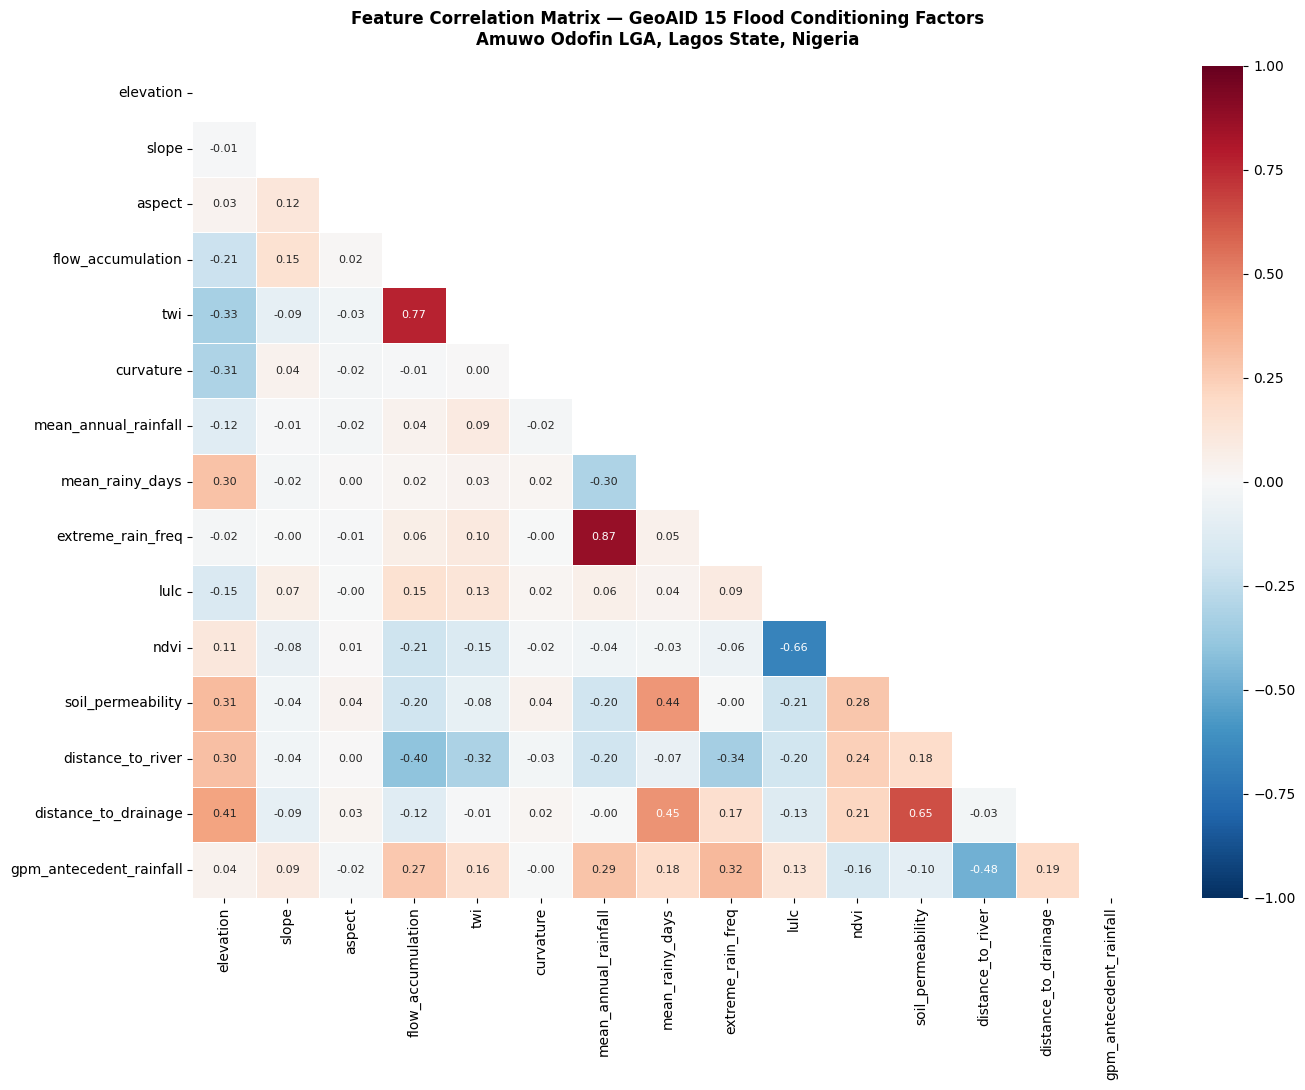


✓ Correlation matrix saved to outputs/figures/correlation_matrix.png


In [12]:
# ── CELL 8: Correlation Matrix ───────────────────────────────────────────────
# Pearson correlation matrix identifies linearly correlated feature pairs.
# |r| > 0.8 = high correlation — flag for methodology discussion.
# High correlation does not require feature removal for tree-based models
# (RF, XGBoost handle it well) but distorts Logistic Regression
# coefficient estimates — document in methodology chapter.

feature_cols = [c for c in feature_matrix.columns
                if c not in ['longitude', 'latitude', 'flood_label']]

X = feature_matrix[feature_cols]

corr_matrix = X.corr()

# Flag highly correlated pairs
print("Highly correlated feature pairs (|r| > 0.7):")
print()
flagged = False
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {feature_cols[i]} ↔ {feature_cols[j]}: r = {r:.3f}")
            flagged = True
if not flagged:
    print("  No pairs exceed |r| > 0.7")

# Plot correlation matrix
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask       = mask,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'RdBu_r',
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    linewidths = 0.5,
    annot_kws  = {'size': 8},
    ax         = ax
)
ax.set_title(
    'Feature Correlation Matrix — GeoAID 15 Flood Conditioning Factors\n'
    'Amuwo Odofin LGA, Lagos State, Nigeria',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correlation_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print()
print("✓ Correlation matrix saved to outputs/figures/correlation_matrix.png")

In [ ]:
# ── CELL 9: Variance Inflation Factor Analysis ────────────────────────────────
# VIF measures how much the variance of a regression coefficient is
# inflated by correlation with other features.
# VIF < 5  : acceptable
# VIF 5-10 : moderate — note in methodology, monitor LR performance
# VIF > 10 : high — problematic for Logistic Regression interpretation
#
# Tree-based models (RF, XGBoost) are largely immune to multicollinearity.
# VIF analysis primarily informs Logistic Regression baseline model.

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    X_clean = X[feature_cols].replace([np.inf, -np.inf], np.nan).dropna()

    vif_data = pd.DataFrame({
        'Feature': feature_cols,
        'VIF'    : [variance_inflation_factor(X_clean.values, i)
                    for i in range(len(feature_cols))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

    print("Variance Inflation Factor (VIF) Analysis:")
    print(f"  {'Feature':<30} {'VIF':>8}  Flag")
    print("  " + "-" * 50)

    for _, row in vif_data.iterrows():
        if row['VIF'] > 10:
            flag = '⚠ HIGH — review for LR model'
        elif row['VIF'] > 5:
            flag = '⚡ MODERATE'
        else:
            flag = '✓'
        print(f"  {row['Feature']:<30} {row['VIF']:>8.2f}  {flag}")

    print()
    high_vif = vif_data[vif_data['VIF'] > 10]
    if len(high_vif) > 0:
        print(f"  ⚠ {len(high_vif)} features with VIF > 10")
        print("    These will not be removed — tree models handle multicollinearity.")
        print("    LR coefficients for these features should be interpreted cautiously.")
    else:
        print("  ✓ All VIF values acceptable")

except ImportError:
    print("statsmodels not installed — installing now")
    os.system("pip3 install statsmodels")
    print("Re-run this cell after installation completes")

In [ ]:
# ── CELL 10: Save Final ML-Ready Feature Matrix ───────────────────────────────

output_data    = os.path.join(DATA_DIR, 'feature_matrix.csv')
output_outputs = os.path.join(OUTPUTS_DIR, 'feature_matrix.csv')

feature_matrix.to_csv(output_data,    index=False)
feature_matrix.to_csv(output_outputs, index=False)

print("✓ Feature matrix saved")
print(f"  Working copy : {output_data}")
print(f"  Archive copy : {output_outputs}")
print()
print("Final Feature Matrix Summary:")
print(f"  Total samples  : {len(feature_matrix):,}")
print(f"  Total features : {len(feature_cols)}")
print(f"  Flood (1)      : {(feature_matrix['flood_label']==1).sum():,}")
print(f"  Non-flood (0)  : {(feature_matrix['flood_label']==0).sum():,}")
print()
print("Feature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2}. {col}")

In [ ]:
# ── CELL 11: Session Summary ─────────────────────────────────────────────────
print("=" * 60)
print("  NOTEBOOK 06 — FEATURE MATRIX ASSEMBLY: COMPLETE")
print("=" * 60)
print()
print("  Operations completed:")
print("  ├── Raster metadata inspection ✓")
print("  ├── All rasters resampled to common 100m grid ✓")
print("  ├── Training points CSV loaded and parsed ✓")
print("  ├── Spatial join: 10,000 points × 15 features ✓")
print("  ├── Missing value handling ✓")
print("  ├── Correlation matrix computed and saved ✓")
print("  ├── VIF analysis completed ✓")
print("  └── feature_matrix.csv saved ✓")
print()
print("  Output: data/feature_matrix.csv")
print()
print("  Next: 07_model_training.ipynb")
print("        → Logistic Regression (baseline)")
print("        → Random Forest (primary model)")
print("        → XGBoost (benchmark)")
print("        → Spatial k-fold cross-validation")
print("        → ROC curves and performance metrics")
print("        → Flood risk map generation")
print("=" * 60)